# Modeling Flight Delay Propagation

This notebook analyzes how delays propagate across an individual aircraft's daily route sequence. The objective is to build a Markov chain representation of flight-state transitions and estimate the transition matrix that governs movement between on-time and delay states.

The analysis uses BTS Marketing Carrier On-Time Performance data for July 2025 from the [BTS TranStats portal](https://www.transtats.bts.gov/tables.asp?QO_VQ=EFD&QO_anzr=Nv4yv0r). The dataset includes:
- `DAY_OF_WEEK` (int): Numeric day-of-week indicator
- `FL_DATE` (string): Flight date in `m/d/yyyy 12:00:00 AM` format
- `OP_CARRIER_AIRLINE_ID` (int): DOT-assigned operating airline identifier
- `TAIL_NUM` (string): Aircraft tail number
- `OP_CARRIER_FL_NUM` (int): Operating airline flight number
- `ORIGIN` (string): Origin airport IATA code
- `ORIGIN_CITY_NAME` (string): Origin city
- `DEST` (string): Destination airport IATA code
- `DEST_CITY_NAME` (string): Destination city
- `CRS_DEP_TIME` (int): Scheduled local departure time (`hhmm`)
- `DEP_TIME` (float64): Actual local departure time (`hhmm`)
- `DEP_DELAY` (float64): Departure delay in minutes (negative indicates early departure)
- `CRS_ARR_TIME` (int): Scheduled local arrival time (`hhmm`)
- `ARR_TIME` (float64): Actual local arrival time (`hhmm`)
- `ARR_DELAY` (float64): Arrival delay in minutes (negative indicates early arrival)
- `CANCELLED` (float64): `1` if the flight was cancelled
- `DIVERTED` (float64): `1` if the flight was diverted
- `DUP` (string): Flag indicating a swapped/duplicate record
- `CRS_ELAPSED_TIME` (float64): Scheduled flight time in minutes
- `ACTUAL_ELAPSED_TIME` (float64): Actual flight time in minutes

## Notebook Roadmap
1. Assess missingness and clean unusable records
2. Standardize local time fields and convert scheduled departures to UTC
3. Define flight delay states for Markov modeling
4. Build aircraft-day chains and estimate transition probabilities
5. Compute and visualize the stationary distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import airportsdata

In [2]:
#import data
delay_df = pd.read_csv('data/flight_delays.csv')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME
0,1,7/7/2025 12:00:00 AM,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,508.0,3.0,630,622.0,-8.0,0.0,0.0,N,205.0,194.0
1,1,7/7/2025 12:00:00 AM,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,2227.0,297.0,1915,2.0,287.0,0.0,0.0,N,165.0,155.0
2,1,7/7/2025 12:00:00 AM,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,1925.0,315.0,1640,2148.0,308.0,0.0,0.0,N,90.0,83.0
3,1,7/7/2025 12:00:00 AM,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,724.0,14.0,1325,1828.0,NaN,0.0,1.0,N,255.0,NaN
4,1,7/7/2025 12:00:00 AM,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,2229.0,69.0,2350,40.0,50.0,0.0,0.0,N,150.0,131.0


### Data Snapshot and Scope

The following preview confirms the schema and gives a quick sanity check before cleaning and transformation. The analysis focuses on sequence behavior by aircraft tail number; therefore, records without `TAIL_NUM` are excluded later in preprocessing.

## Data Missingness Analysis

In [3]:
delay_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 696049 entries, 0 to 696048
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DAY_OF_WEEK            696049 non-null  int64  
 1   FL_DATE                696049 non-null  str    
 2   OP_CARRIER_AIRLINE_ID  696049 non-null  int64  
 3   TAIL_NUM               693619 non-null  str    
 4   OP_CARRIER_FL_NUM      696049 non-null  int64  
 5   ORIGIN_AIRPORT_ID      696049 non-null  int64  
 6   ORIGIN                 696049 non-null  str    
 7   ORIGIN_CITY_NAME       696049 non-null  str    
 8   DEST                   696049 non-null  str    
 9   DEST_CITY_NAME         696049 non-null  str    
 10  CRS_DEP_TIME           696049 non-null  int64  
 11  DEP_TIME               679234 non-null  float64
 12  DEP_DELAY              679172 non-null  float64
 13  CRS_ARR_TIME           696049 non-null  int64  
 14  ARR_TIME               677870 non-null  float64

In [4]:
delay_df.isnull().sum()

DAY_OF_WEEK                  0
FL_DATE                      0
OP_CARRIER_AIRLINE_ID        0
TAIL_NUM                  2430
OP_CARRIER_FL_NUM            0
ORIGIN_AIRPORT_ID            0
ORIGIN                       0
ORIGIN_CITY_NAME             0
DEST                         0
DEST_CITY_NAME               0
CRS_DEP_TIME                 0
DEP_TIME                 16815
DEP_DELAY                16877
CRS_ARR_TIME                 0
ARR_TIME                 18179
ARR_DELAY                21308
CANCELLED                    0
DIVERTED                     0
DUP                          0
CRS_ELAPSED_TIME             0
ACTUAL_ELAPSED_TIME      21308
dtype: int64

In [5]:
# view flights with null tail numbers
delay_df[ delay_df['TAIL_NUM'].isnull() ].sample(5)

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME
154141,2,7/15/2025 12:00:00 AM,20378,NaN,6035,11481,ECP,"Panama City, FL",IAH,"Houston, TX",...,NaN,NaN,832,NaN,NaN,1.0,0.0,N,122.0,NaN
394408,4,7/24/2025 12:00:00 AM,19977,NaN,205,11292,DEN,"Denver, CO",BZN,"Bozeman, MT",...,NaN,NaN,2132,NaN,NaN,1.0,0.0,N,107.0,NaN
148622,2,7/15/2025 12:00:00 AM,19977,NaN,2310,11618,EWR,"Newark, NJ",MYR,"Myrtle Beach, SC",...,NaN,NaN,957,NaN,NaN,1.0,0.0,N,117.0,NaN
115390,2,7/1/2025 12:00:00 AM,20500,NaN,4442,11278,DCA,"Washington, DC",EWR,"Newark, NJ",...,NaN,NaN,1419,NaN,NaN,1.0,0.0,N,79.0,NaN
558578,6,7/12/2025 12:00:00 AM,20436,NaN,3407,11057,CLT,"Charlotte, NC",TPA,"Tampa, FL",...,NaN,NaN,2328,NaN,NaN,1.0,0.0,N,111.0,NaN


It appears that flights with null tail numbers are due to being cancelled.

In [6]:
#count of cancelled flights
delay_df.CANCELLED.value_counts()

CANCELLED
0.0    678101
1.0     17948
Name: count, dtype: int64

In [7]:
#count of duplicate flights
delay_df.DUP.value_counts()

DUP
N    696049
Name: count, dtype: int64

In [8]:
#count of diverted flights
delay_df.DIVERTED.value_counts()

DIVERTED
0.0    692689
1.0      3360
Name: count, dtype: int64

In [9]:
#count nulls among non-cancelled flights
delay_df[delay_df.CANCELLED == 0].isnull().sum()

DAY_OF_WEEK                 0
FL_DATE                     0
OP_CARRIER_AIRLINE_ID       0
TAIL_NUM                    0
OP_CARRIER_FL_NUM           0
ORIGIN_AIRPORT_ID           0
ORIGIN                      0
ORIGIN_CITY_NAME            0
DEST                        0
DEST_CITY_NAME              0
CRS_DEP_TIME                0
DEP_TIME                    0
DEP_DELAY                   0
CRS_ARR_TIME                0
ARR_TIME                  231
ARR_DELAY                3360
CANCELLED                   0
DIVERTED                    0
DUP                         0
CRS_ELAPSED_TIME            0
ACTUAL_ELAPSED_TIME      3360
dtype: int64

In [10]:
#count nulls among non-cancelled and non-diverted flights
delay_df[(delay_df.CANCELLED == 0) & (delay_df.DIVERTED == 0)].isnull().sum()

DAY_OF_WEEK              0
FL_DATE                  0
OP_CARRIER_AIRLINE_ID    0
TAIL_NUM                 0
OP_CARRIER_FL_NUM        0
ORIGIN_AIRPORT_ID        0
ORIGIN                   0
ORIGIN_CITY_NAME         0
DEST                     0
DEST_CITY_NAME           0
CRS_DEP_TIME             0
DEP_TIME                 0
DEP_DELAY                0
CRS_ARR_TIME             0
ARR_TIME                 0
ARR_DELAY                0
CANCELLED                0
DIVERTED                 0
DUP                      0
CRS_ELAPSED_TIME         0
ACTUAL_ELAPSED_TIME      0
dtype: int64

We can see that most null values are attributed to the flight being cancelled with the exception of arrival time and arrival delay. According to the BTS metadata, flights that were diverted end up having null arrival times. If we observe non-cancelled and non-diverted flights, we can see that there is no data missing. All null values can be attributed to cancelled and diverted flights in this dataset. We can drop null tail numbers, since tail numbers are crucial to assigning flights to chains.

In [11]:
delay_df = delay_df.dropna(subset="TAIL_NUM")

## Time Handling

Time fields must be standardized before chain construction. In the raw data, `FL_DATE` is string-formatted and scheduled/actual departure fields are numeric rather than timestamp values.

In addition, the timestamps are recorded in local airport time. Because aircraft sequences can cross time zones, we convert scheduled departures to a UTC-based timeline before assigning flights to ordered chains.

A practical operating-day boundary is also needed. Based on the schedule distribution, we treat an aircraft operating day as running from 5:00 AM to 5:00 AM the following calendar day.

In [12]:
#convert FL_DATE to datetime
delay_df['FL_DATE'] = pd.to_datetime(delay_df['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [13]:
#Format local CRS departure time 

#pad to 4 digits
delay_df['CRS_DEP_LT'] = pd.to_numeric(delay_df['CRS_DEP_TIME'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(4)

#replace flights at midnight with 2359 for dt handling
delay_df['CRS_DEP_LT'] = delay_df['CRS_DEP_LT'].replace('2400', '2359')

#convert to datetime
delay_df['CRS_DEP_LT'] = pd.to_datetime(delay_df['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + delay_df['CRS_DEP_LT'].str[:2] + ':' + delay_df['CRS_DEP_LT'].str[2:], format='%Y-%m-%d %H:%M', errors='coerce')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT
0,1,2025-07-07,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,3.0,630,622.0,-8.0,0.0,0.0,N,205.0,194.0,2025-07-07 05:05:00
1,1,2025-07-07,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,297.0,1915,2.0,287.0,0.0,0.0,N,165.0,155.0,2025-07-07 17:30:00
2,1,2025-07-07,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,315.0,1640,2148.0,308.0,0.0,0.0,N,90.0,83.0,2025-07-07 14:10:00
3,1,2025-07-07,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,14.0,1325,1828.0,NaN,0.0,1.0,N,255.0,NaN,2025-07-07 07:10:00
4,1,2025-07-07,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,69.0,2350,40.0,50.0,0.0,0.0,N,150.0,131.0,2025-07-07 21:20:00


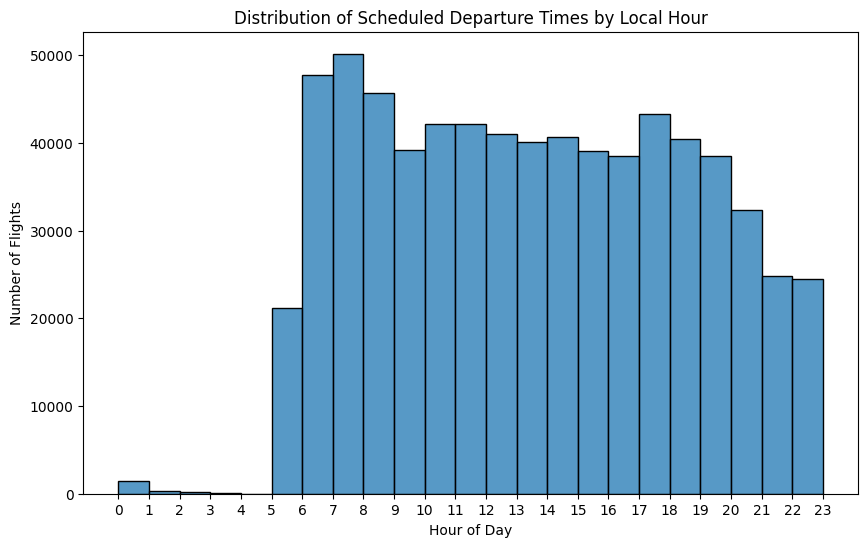

In [14]:
# plot distribution of departure times by the hour
plt.figure(figsize=(10,6))
sns.histplot(delay_df['CRS_DEP_LT'].dt.hour, bins=23, kde=False)
plt.title('Distribution of Scheduled Departure Times by Local Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.xticks(range(0,24))
plt.show()
plt.close()

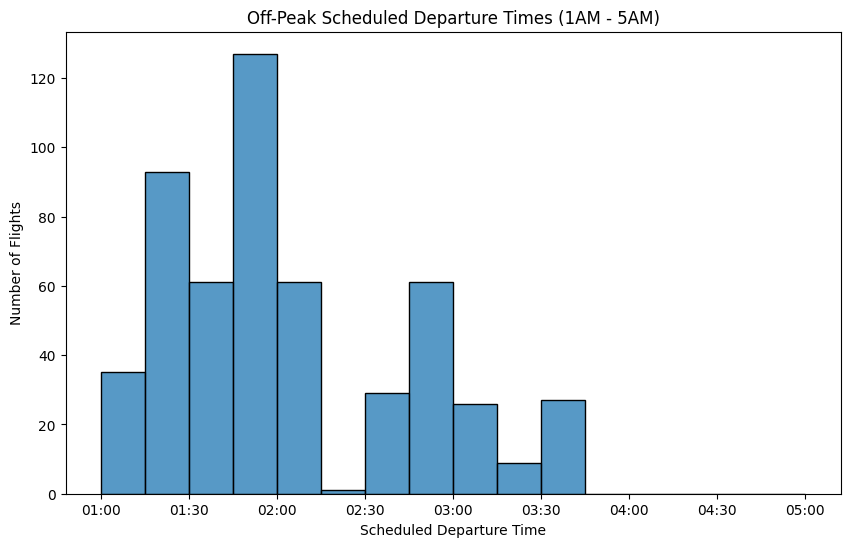

In [15]:
# plot off-peak departure in 15 minute intervals (1am-4am)
off_hour_flights = delay_df[ (delay_df['CRS_DEP_LT'].dt.hour < 5) & (delay_df['CRS_DEP_LT'].dt.hour >= 1) ]

off_hour_flights['minutes_of_day'] = (off_hour_flights['CRS_DEP_LT'].dt.hour * 60 + off_hour_flights['CRS_DEP_LT'].dt.minute)

plt.figure(figsize=(10,6))
sns.histplot(
    data=off_hour_flights, 
    x='minutes_of_day', 
    bins=range(60, 315, 15),
    kde=False
)

ticks = range(60, 315, 30)
labels = [f"{m//60:02d}:{m%60:02d}" for m in ticks]
plt.xticks(ticks, labels)

plt.title('Off-Peak Scheduled Departure Times (1AM - 5AM)')
plt.xlabel('Scheduled Departure Time')
plt.ylabel('Number of Flights')
plt.show()
plt.close()

#cleanup
del off_hour_flights

From these plots we can observe that a vast majority of flights are scheduled to depart between 5 AM and 12 AM. Scheduled departures fall off significantly after midnight and no flights were scheduled between 3:45 AM and 5 AM. With this information we can classify an aircraft's operating schedule to be between 5 AM to 5 AM the following day.

In [16]:
delay_df['Operational_Date'] = (delay_df['CRS_DEP_LT'] - pd.Timedelta(hours=5)).dt.date

In [17]:
# Calculate universal departure time
airports = airportsdata.load('IATA')
delay_df['CRS_DEP_UTC'] = pd.NaT

def get_tz(iata_code):
    return airports[iata_code]['tz']

delay_df['DEP_TZ'] = delay_df['ORIGIN'].apply(get_tz)

#process timezones in groups
for tz, group in delay_df.groupby('DEP_TZ'):
    utc = (group['CRS_DEP_LT'].dt.tz_localize(tz, ambiguous='NaT', nonexistent='NaT').dt.tz_convert('UTC').dt.tz_localize(None))

    delay_df.loc[group.index, 'CRS_DEP_UTC'] = utc

delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ
0,1,2025-07-07,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,-8.0,0.0,0.0,N,205.0,194.0,2025-07-07 05:05:00,2025-07-07,2025-07-07 10:05:00,America/Chicago
1,1,2025-07-07,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,287.0,0.0,0.0,N,165.0,155.0,2025-07-07 17:30:00,2025-07-07,2025-07-07 21:30:00,America/New_York
2,1,2025-07-07,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,308.0,0.0,0.0,N,90.0,83.0,2025-07-07 14:10:00,2025-07-07,2025-07-07 19:10:00,America/Chicago
3,1,2025-07-07,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,NaN,0.0,1.0,N,255.0,NaN,2025-07-07 07:10:00,2025-07-07,2025-07-07 14:10:00,America/Los_Angeles
4,1,2025-07-07,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,50.0,0.0,0.0,N,150.0,131.0,2025-07-07 21:20:00,2025-07-07,2025-07-08 01:20:00,America/New_York


In [18]:
# Create actual depature time in local time
delay_df['DEP_TIME_LT'] = delay_df['CRS_DEP_LT'] + pd.to_timedelta(delay_df['DEP_DELAY'], unit='m')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ,DEP_TIME_LT
0,1,2025-07-07,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,0.0,0.0,N,205.0,194.0,2025-07-07 05:05:00,2025-07-07,2025-07-07 10:05:00,America/Chicago,2025-07-07 05:08:00
1,1,2025-07-07,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,0.0,0.0,N,165.0,155.0,2025-07-07 17:30:00,2025-07-07,2025-07-07 21:30:00,America/New_York,2025-07-07 22:27:00
2,1,2025-07-07,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,0.0,0.0,N,90.0,83.0,2025-07-07 14:10:00,2025-07-07,2025-07-07 19:10:00,America/Chicago,2025-07-07 19:25:00
3,1,2025-07-07,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,0.0,1.0,N,255.0,NaN,2025-07-07 07:10:00,2025-07-07,2025-07-07 14:10:00,America/Los_Angeles,2025-07-07 07:24:00
4,1,2025-07-07,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,0.0,0.0,N,150.0,131.0,2025-07-07 21:20:00,2025-07-07,2025-07-08 01:20:00,America/New_York,2025-07-07 22:29:00


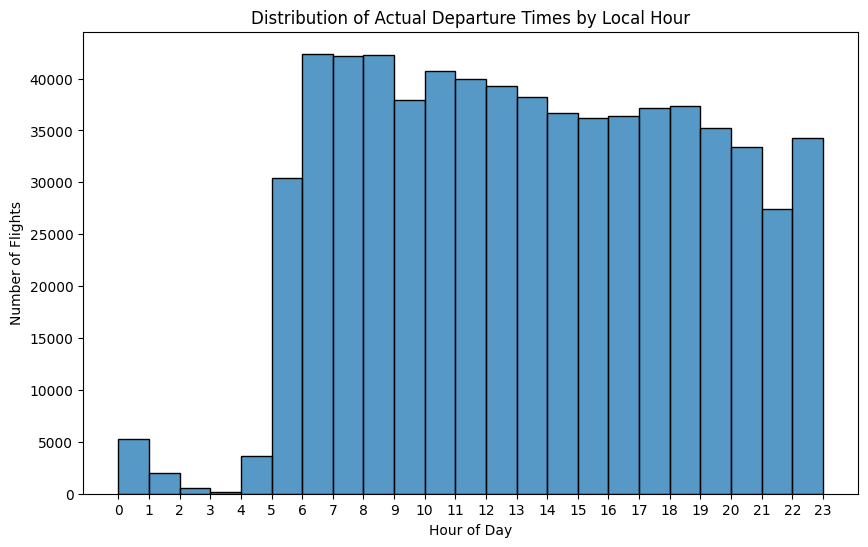

In [19]:
# plot distribution of actual departure times by the localhour
plt.figure(figsize=(10,6))
sns.histplot((delay_df['CRS_DEP_LT'] + pd.to_timedelta(delay_df['DEP_DELAY'], unit='m')).dt.hour, bins=23, kde=False)
plt.title('Distribution of Actual Departure Times by Local Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.xticks(range(0,24))
plt.show()
plt.close()

## Assign States to Flights

We assign each flight to a discrete state so that each aircraft-day sequence can be modeled as a Markov chain.

State definitions:

0. On-time: arrival delay < 15 minutes
1. Delayed: arrival delay >= 15 minutes (FAA threshold)
2. Significant delay: arrival delay >= 60 minutes
3. Extreme departure delay: departure delay >= 120 minutes (chain-disrupting)
4. Cancelled flight
5. Diverted flight

The extreme-delay state is used to represent severe operational disruption that can cascade through downstream legs.

count    674741.000000
mean         17.251113
std          72.638143
min         -83.000000
25%         -13.000000
50%          -3.000000
75%          20.000000
max        2557.000000
Name: ARR_DELAY, dtype: float64


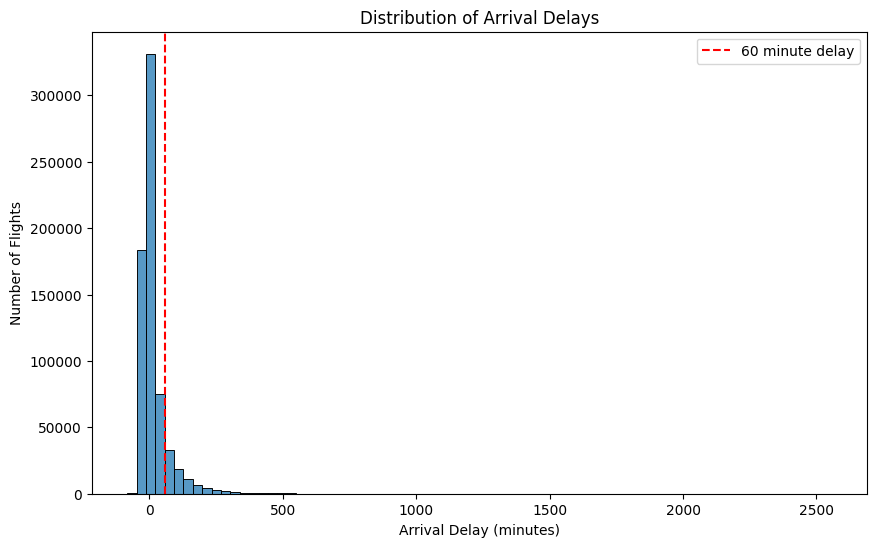

In [20]:
print(delay_df.ARR_DELAY.describe())


# plot distribution of arrival delays
plt.figure(figsize=(10,6))
sns.histplot(delay_df['ARR_DELAY'].dropna(), bins=75, kde=False)
plt.title('Distribution of Arrival Delays')
plt.axvline(60, color='red', linestyle='--', label='60 minute delay')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Number of Flights')
plt.legend()
plt.show()
plt.close()

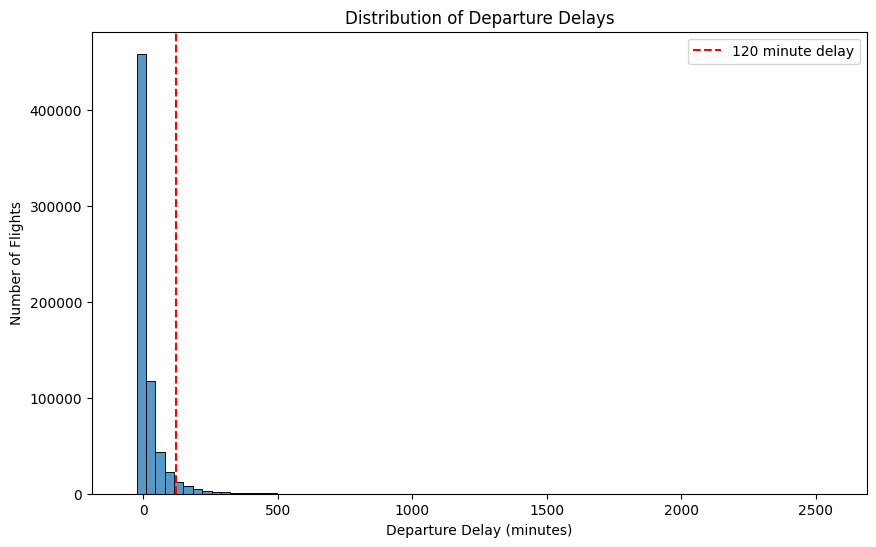

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(delay_df['DEP_DELAY'].dropna(), bins=75, kde=False)
plt.axvline(120, color='red', linestyle='--', label='120 minute delay')
plt.legend()
plt.title('Distribution of Departure Delays')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Number of Flights')
plt.show()
plt.close()

The departure plot shows that a vast majority of flights are on time or slightly delayed. Delay time falls off significantly after 120 minutes. We will use 120 minutes (2 hours) as our cutoff for the rollover delay.

In [22]:
#classify flights as delayed or not 
delay_df['IS_ARR_DELAY'] = delay_df['ARR_DELAY'] >= 15

# set state variable for modeling
delay_df['STATE'] = delay_df['IS_ARR_DELAY'] * 1
extreme_mask = delay_df['ARR_DELAY'] >= 60
delay_df.loc[extreme_mask, 'STATE'] = 2

# define sequence failures
cancelled_mask = delay_df['CANCELLED'] == 1
diverted_mask = delay_df['DIVERTED'] == 1
extreme_mask = delay_df['DEP_DELAY'] >= 120

delay_df.loc[extreme_mask, 'STATE'] = 3
delay_df.loc[cancelled_mask, 'STATE'] = 4
delay_df.loc[diverted_mask, 'STATE'] = 5

delay_df.STATE.value_counts()


STATE
0    481849
1    111360
2     46747
3     34785
4     15518
5      3360
Name: count, dtype: int64

## Assign Flights to Chains

Each chain represents one aircraft (`TAIL_NUM`) over one operational day (`Operational_Date`).
Flights are sorted by scheduled UTC departure time and grouped to create ordered sequences for state-transition estimation.

This produces the trajectory data required to compute one-step transition probabilities between states.

In [23]:
# flights to inorder of scheduled departure time in UTC
delay_df = delay_df.sort_values(by=['TAIL_NUM', 'Operational_Date', 'CRS_DEP_UTC', 'STATE'])

# remove cases of ghost flights, a flight was cancelled, but the aircraft was scheduled for another flight at the same time
delay_df = delay_df.drop_duplicates(subset=['TAIL_NUM', 'Operational_Date', 'CRS_DEP_UTC'], keep='first')

# assign an ID to each chain
delay_df['CHAIN_ID'] = delay_df.groupby(['TAIL_NUM', 'Operational_Date']).ngroup()

Number of chains: 162710


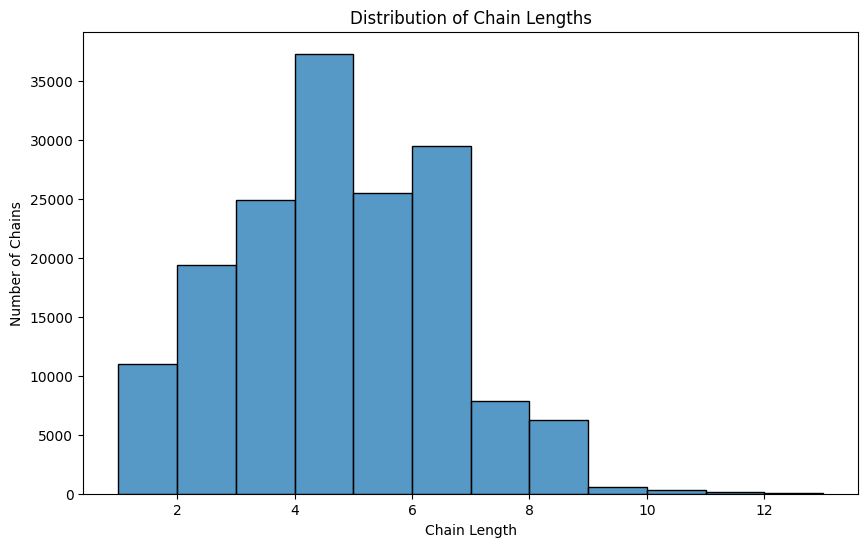

1     10990
2     19396
3     24847
4     37275
5     25513
6     29473
7      7894
8      6257
9       585
10      297
11      142
12       40
13        1
Name: count, dtype: int64


In [24]:
# count the number of chains
print("Number of chains:", delay_df['CHAIN_ID'].nunique())

# plot distribution of chain lengths
chain_lengths = delay_df.groupby('CHAIN_ID').size()
plt.figure(figsize=(10,6))
sns.histplot(chain_lengths, bins=range(1, chain_lengths.max() + 1), kde=False)
plt.title('Distribution of Chain Lengths')
plt.xlabel('Chain Length')
plt.ylabel('Number of Chains')
plt.show()
plt.close()

# count number of chains of each length
chain_length_counts = chain_lengths.value_counts().sort_index()
print(chain_length_counts)

Most aircraft complete roughly 4-6 flights per operating day, with a meaningful share completing only 1-2 legs. A smaller set of aircraft operate many short segments, likely corresponding to regional or shuttle-like schedules.

In [25]:
delay_df[delay_df['CHAIN_ID'] == 12356]

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ,DEP_TIME_LT,IS_ARR_DELAY,STATE,CHAIN_ID
349673,4,2025-07-10,20304,N150SY,4640,12217,HSV,"Huntsville, AL",DEN,"Denver, CO",...,190.0,200.0,2025-07-10 08:09:00,2025-07-10,2025-07-10 13:09:00,America/Chicago,2025-07-10 08:16:00,True,1,12356
349676,4,2025-07-10,20304,N150SY,5506,11292,DEN,"Denver, CO",ACV,"Arcata/Eureka, CA",...,182.0,170.0,2025-07-10 11:29:00,2025-07-10,2025-07-10 17:29:00,America/Denver,2025-07-10 11:33:00,False,0,12356
349674,4,2025-07-10,20304,N150SY,4655,10157,ACV,"Arcata/Eureka, CA",SFO,"San Francisco, CA",...,76.0,61.0,2025-07-10 14:19:00,2025-07-10,2025-07-10 21:19:00,America/Los_Angeles,2025-07-10 14:13:00,False,0,12356
349677,4,2025-07-10,20304,N150SY,5664,14771,SFO,"San Francisco, CA",EUG,"Eugene, OR",...,98.0,84.0,2025-07-10 16:10:00,2025-07-10,2025-07-10 23:10:00,America/Los_Angeles,2025-07-10 16:09:00,False,0,12356
349678,4,2025-07-10,20304,N150SY,5838,11603,EUG,"Eugene, OR",SFO,"San Francisco, CA",...,101.0,84.0,2025-07-10 18:29:00,2025-07-10,2025-07-11 01:29:00,America/Los_Angeles,2025-07-10 18:20:00,False,0,12356
349675,4,2025-07-10,20304,N150SY,4737,14771,SFO,"San Francisco, CA",BFL,"Bakersfield, CA",...,75.0,81.0,2025-07-10 21:30:00,2025-07-10,2025-07-11 04:30:00,America/Los_Angeles,2025-07-10 21:27:00,False,0,12356


## Transition Matrix

In [26]:
# create a column for the next state in the chain
delay_df['NEXT_STATE'] = delay_df.groupby('CHAIN_ID')['STATE'].shift(-1)
transitions = delay_df.dropna(subset=['NEXT_STATE'])

transition_matrix = pd.crosstab(
    transitions['STATE'],       
    transitions['NEXT_STATE'], 
    normalize='index' 
).round(4)

print(transition_matrix)

NEXT_STATE     0.0     1.0     2.0     3.0     4.0     5.0
STATE                                                     
0           0.7897  0.1297  0.0402  0.0247  0.0101  0.0056
1           0.3645  0.4511  0.1130  0.0454  0.0208  0.0052
2           0.0911  0.2564  0.4547  0.1514  0.0412  0.0052
3           0.1534  0.0901  0.1481  0.5184  0.0854  0.0047
4           0.2599  0.1198  0.0779  0.0902  0.4486  0.0036
5           0.0427  0.0508  0.1034  0.6223  0.1772  0.0036


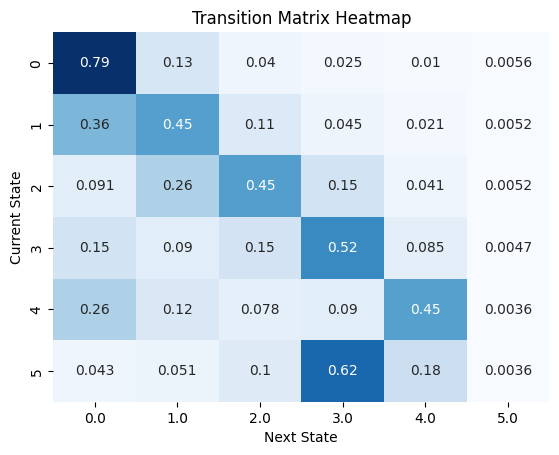

In [33]:
sns.heatmap(transition_matrix, annot=True, cmap='Blues', cbar_kws={'label': 'Transition Probability'}, cbar=False)
plt.title('Transition Matrix Heatmap')
plt.xlabel('Next State')
plt.ylabel('Current State')
plt.show()
plt.close()

The transition matrix indicates strong persistence: aircraft are most likely to remain in their current delay regime from one leg to the next. As delay severity increases, the probability mass shifts toward more disruptive downstream states (including cancellation and diversion), consistent with delay propagation dynamics.

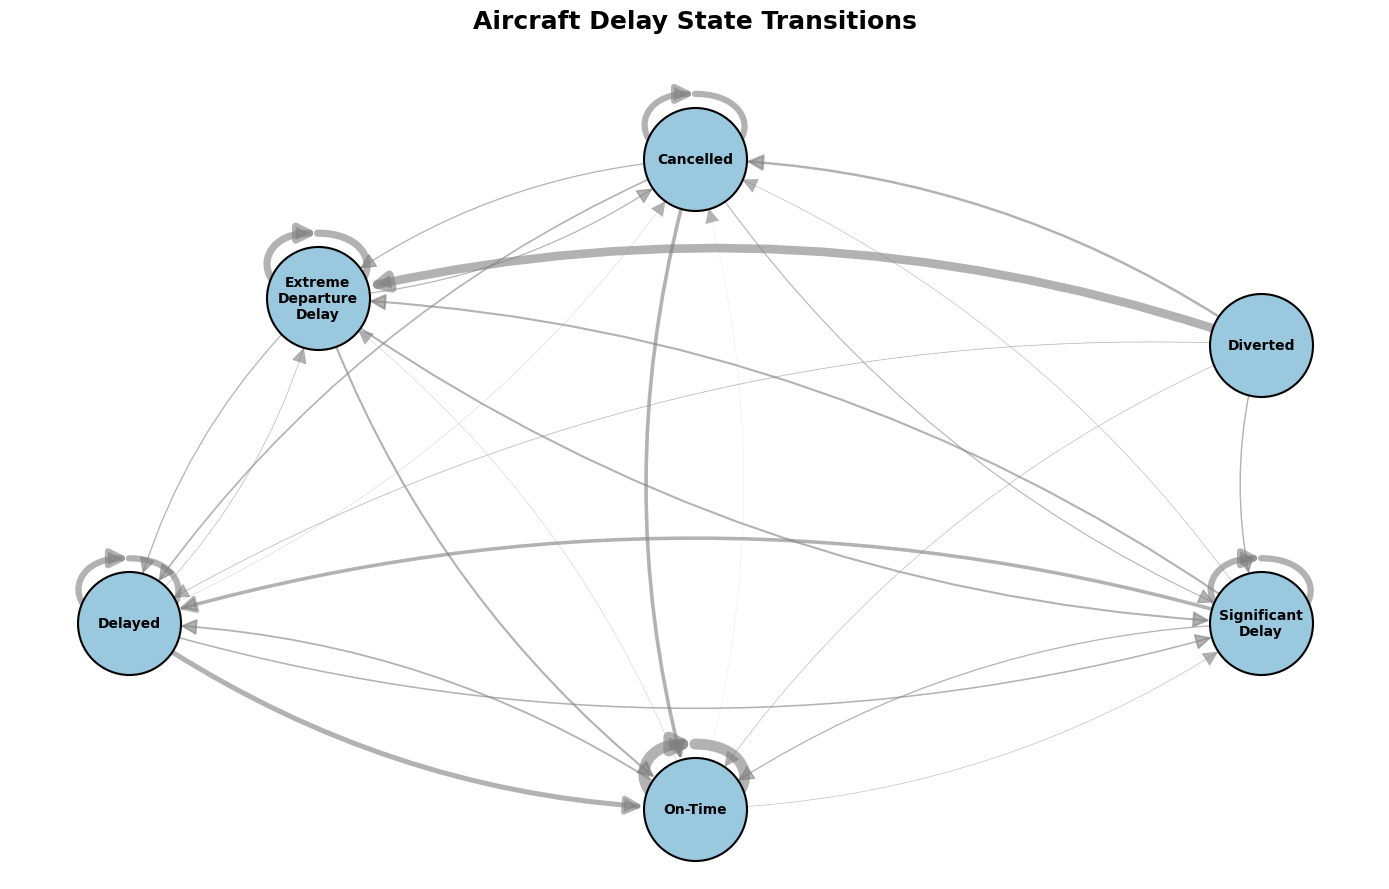

In [27]:
# Visualize directed graph
dg = nx.DiGraph()

state_labels = {
    0.0: 'On-Time',
    1.0: 'Delayed',
    2.0: 'Significant\nDelay',
    3.0: 'Extreme\nDeparture\nDelay',
    4.0: 'Cancelled',
    5.0: 'Diverted'
}

# for simiplicity only show transitions above 1%
threshold = .01

for current_state in transition_matrix.index:
    for next_state in transition_matrix.columns:
        prob = transition_matrix.loc[current_state, next_state]
        
        if prob >= threshold:
            dg.add_edge(
                state_labels[current_state], 
                state_labels[next_state], 
                weight=prob
            )

pos = {
    'On-Time': (0, -3),         
    'Delayed': (-3, -1),        
    'Extreme\nDeparture\nDelay': (-2, 2.5),
    'Cancelled': (0, 4),        
    'Diverted': (3, 2),         
    'Significant\nDelay': (3, -1)  
}

edge_widths = [dg[u][v]['weight'] * 10 for u, v in dg.edges()]

plt.figure(figsize=(14, 9))
nx.draw_networkx_edges(
    dg, pos, 
    node_size=5500,           
    width=edge_widths, 
    arrowstyle='-|>', 
    arrowsize=25, 
    edge_color='gray', 
    alpha=0.6,
    connectionstyle='arc3,rad=0.15' 
)

nx.draw_networkx_nodes(
    dg, pos, 
    node_size=5500, 
    node_color='#99C8DF', 
    edgecolors='black', 
    linewidths=1.5
)

nx.draw_networkx_labels(dg, pos, font_size=10, font_weight='bold')

plt.title("Aircraft Delay State Transitions", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

## Stationary Distribution

The **stationary distribution** ($\pi$) is the long-term equilibrium of our flight network. It tells us what percentage of flights end up in each state after the system has been running for a long time.

the stationary distribution must satisfy **$\pi P = \pi$**. This just means that if you multiply our steady state by the transition matrix ($P$), the probabilities don't change anymore.

In [28]:
# Calculate stationary distribution with eigen decomposition
matrix = transition_matrix.to_numpy()

eigenvalues, eigenvectors = np.linalg.eig(matrix.T)

eigenvalue_index = np.argmin(np.abs(eigenvalues - 1.0))
steady_state_vector = eigenvectors[:, eigenvalue_index]
stationary_distribution = steady_state_vector / np.sum(steady_state_vector)

for state_id, prob in zip(transition_matrix.columns, stationary_distribution):
    label = state_labels[state_id].replace('\n', ' ')
    print(f"{label:<20}: {prob:.2%}")


On-Time             : 53.24%
Delayed             : 20.58%
Significant Delay   : 11.56%
Extreme Departure Delay: 9.79%
Cancelled           : 4.30%
Diverted            : 0.53%


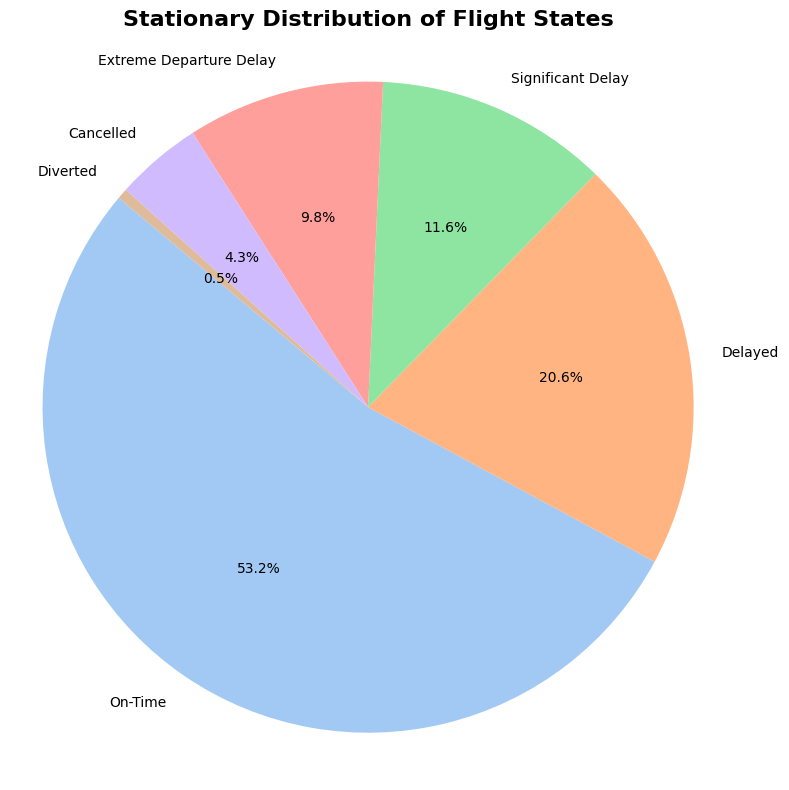

In [29]:
# pie chart of stationary distribution
labels = state_labels.values()
labels = [x.replace('\n', ' ') for x in labels]
plt.figure(figsize=(8, 8))
plt.pie(stationary_distribution, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Stationary Distribution of Flight States', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [35]:
#TODO: conduct seaonality analysis and compare airline performance